In [ ]:
# Inhalt ansehen

import os
dataset_path = "/kaggle/input/datasets/dhruv413/gaze-capture-20gb-zip"

i = 0
for root, dirs, files in os.walk(dataset_path):
    i += 1
    print("ROOT:", root)
    print("FILES:", files[:10])
    print("*" * 60)

    if i > 8:
        break




In [1]:
# Step 0:
! pip install datasets huggingface_hub pandas pillow
! pip install -U huggingface_hub


In [2]:
# Step 1:

from huggingface_hub import snapshot_download
import os

#DATASET_REPO = "RafeiKAr/my_dataset_gaze"
DATASET_REPO = "RafeiKAr/gaze-estimation_gazecapture"

LOCAL_DATASET_DIR = "./data"

if not os.path.exists(LOCAL_DATASET_DIR):
    print("Lade Dataset von Hugging Face herunter...")

    snapshot_download(
        repo_id=DATASET_REPO,
        repo_type="dataset",
        local_dir=LOCAL_DATASET_DIR,
        local_dir_use_symlinks=False
    )

    print("Download fertig.")
else:
    print("Dataset bereits vorhanden.")

Lade Dataset von Hugging Face herunter...


/home/ari/PycharmProjects/Ven/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Download fertig.


In [3]:
images_dir = "./data/images"
labels_file = "./data/labels.csv"

In [4]:
import pandas as pd

df = pd.read_csv("./data/labels.csv")

print(df.head())
print("Anzahl Samples:", len(df))

        image_name           x           y
0  00002_00000.jpg  160.000000  284.000000
1  00002_00001.jpg  160.000000  284.000000
2  00002_00002.jpg  160.000000  284.000000
3  00002_00003.jpg  160.000000  284.000000
4  00002_00004.jpg  279.657292   64.965084
Anzahl Samples: 21844


In [5]:
# Step 4:

print("Anzahl Samples:", len(df))


Anzahl Samples: 21844


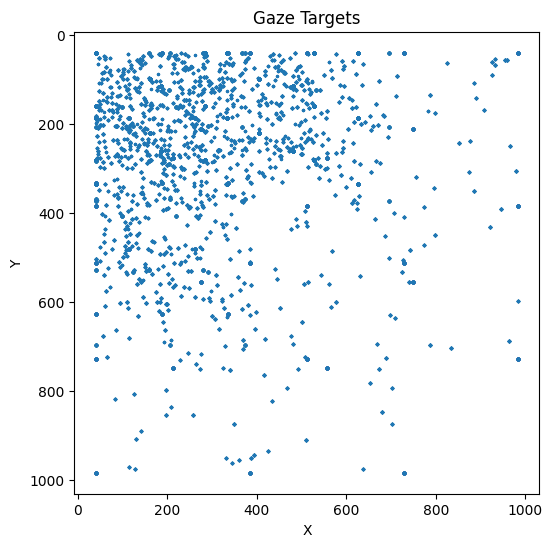

In [6]:
# Step 5:

import matplotlib.pyplot as plt

x = df["x"]
y = df["y"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()


In [7]:
screen_w = df["x"].max()
screen_h = df["y"].max()

print(screen_w, screen_h)

984.0 984.0


In [11]:
# Step 6.1. Constante Baseline

import numpy as np

x_true = df["x"].values
y_true = df["y"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

errors = np.sqrt(
    (x_true - pred_x_const)**2 +
    (y_true - pred_y_const)**2
)

print("\nKonstante Baseline: \n")
print(f"Mean Error: {np.mean(errors)}")
#print("Median Error:", np.median(errors))

print(
    f"Error %: {100*np.mean(errors)/screen_w:.2f}%"
)

print(f"Diagonal-Error %: {100*np.round(np.mean(errors) / np.sqrt(2*screen_w**2), 3)} %")


Konstante Baseline: 

Mean Error: 268.5927937860636
Error %: 27.30%
Diagonal-Error %: 19.3 %


In [10]:
# 6.2. random Baseline

pred_x_random = np.random.uniform(
    0,
    screen_w,
    len(x_true)
)

pred_y_random = np.random.uniform(
    0,
    screen_h,
    len(y_true)
)

errors_random = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

print("\nRandom Baseline: \n")
print(f"\nMean Error: {np.mean(errors_random)}\n")

print(f"Error %: {np.round(np.mean(errors_random) / screen_w, 3)*100} %")

print(f"Diagonal-Error %: {100*np.round(np.mean(errors_random) / np.sqrt(2*screen_w**2), 3)} %")

Random Baseline
Mean Error: 513.7782718568463
Error %: 52.2 %
Diagonal-Error %: 36.9 %


In [ ]:

# Step 1: Verstehen, was in dofInfo.json steckt.

import json
import os

subject_path = "/kaggle/input/datasets/dhruv413/gaze-capture-20gb-zip/00114/00114"

with open(os.path.join(subject_path, "dotInfo.json")) as f:
    dotinfo = json.load(f)

print(type(dotinfo))
print(dotinfo.keys() if isinstance(dotinfo, dict) else dotinfo[:3])


###################################
# Step 2: check the size of Monitor

with open(os.path.join(subject_path, "screen.json")) as f:
    screen = json.load(f)

#print(f"Screen: {screen}")

###################################
# Step 3: check the number of frames

frames_path = os.path.join(subject_path, "frames")

frames = os.listdir(frames_path)

print("Anzahl Frames:", len(frames))
print(frames[:10])

###################################
# step 4: check the size of Xpts, Ypts, frames

print(len(dotinfo["XPts"]))
print(len(dotinfo["YPts"]))
print(len(frames))
    
###################################
# Step 5: visualisieren - Gaze points plot

import matplotlib.pyplot as plt

x = dotinfo["XPts"]
y = dotinfo["YPts"]

print(f"X_max:{max(x)}, Y_max: {max(y)}")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()
    
###################################
# Step 6: create baseline
# Step 6_1: constante Baseline

# Mittelpunkt-Baseline

import numpy as np

x_true = np.array(dotinfo["XPts"])
y_true = np.array(dotinfo["YPts"])

x_const = np.mean(x_true)
y_const = np.mean(y_true)

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

###################################
errors = np.sqrt(
    (x_true - pred_x_const)**2 +
    (y_true - pred_y_const)**2
)

# anhand screen.json
screen_w = 568
screen_h = 568

print("konstante Baseline:")
print("Mean Error:", np.mean(errors))
print("Median Error:", np.median(errors))

print(f"Error in Prozent: {np.round(np.mean(errors) / screen_w, 3)*100} %")

print(f"Diagonal-Error in Prozent: {np.round(np.mean(errors) / np.sqrt(2*screen_w**2)*100, 3)} %")

###################################
# Step 6_2: Random Baseline

# anhand screen.json
screen_w = 568
screen_h = 568


pred_x_random = np.random.uniform(0, screen_w, len(x_true))
pred_y_random = np.random.uniform(0, screen_h, len(y_true))

errors_random = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

print("Random Baseline:")
print("Random Mean Error:", np.mean(errors_random))

print(f"Error in Prozent: {np.round(np.mean(errors_random) / screen_w, 3)*100} %")

print(f"Diagonal-Error in Prozent: {np.round(np.mean(errors_random) / np.sqrt(2*screen_w**2)*100, 3)} %")

